In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.rcParams['font.family'] = 'Arial'

from func_data_prep import process_string, scale_feature_by_daily_intake, get_var_type, get_var_type_color
from func_modeling import calculate_vif, run_all_diagnostics, try_transformations, recommend_transformation, back_transform_effects
from statsmodels.formula.api import ols

from tqdm import tqdm
import networkx as nx

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

/Users/rohansingh/miniconda3/envs/openai_di/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Load data


In [2]:
meta = pd.read_csv("../data/meta_meal_patterns.csv")

meta["HEI_Quartile"] = pd.Categorical(
    meta["HEI_Quartile"], categories=["Q1", "Q2", "Q3", "Q4"], ordered=True
)
meta["bmi_cat"] = pd.Categorical(
    meta["bmi_cat"],
    categories=["Underweight", "Normal", "Overweight", "Obese"],
    ordered=True,
)
meta["age_group_2"] = pd.Categorical(
    meta["age_group_2"], categories=["<35", "35-50", ">50"], ordered=True
)

In [3]:
merged_meals_with_meta = pd.read_pickle("../data/merged_meals_with_meta.pkl")

# merged_meals_with_meta = merged_meals_with_meta[
#     merged_meals_with_meta["energy_kcal_eaten"] > 250
# ]

merged_meals_with_meta["eaten_at"] = pd.to_datetime(merged_meals_with_meta["eaten_at"])
merged_meals_with_meta["eaten_date"] = pd.to_datetime(
    merged_meals_with_meta["eaten_at"].dt.date
)

# # Extract the hour from 'local_eaten_at'
# merged_meals_with_meta['eaten_hour'] = merged_meals_with_meta['local_eaten_at'].dt.hour

print(merged_meals_with_meta.shape)

(65838, 205)


### Scale the energy distribution by meal & Plot correlation

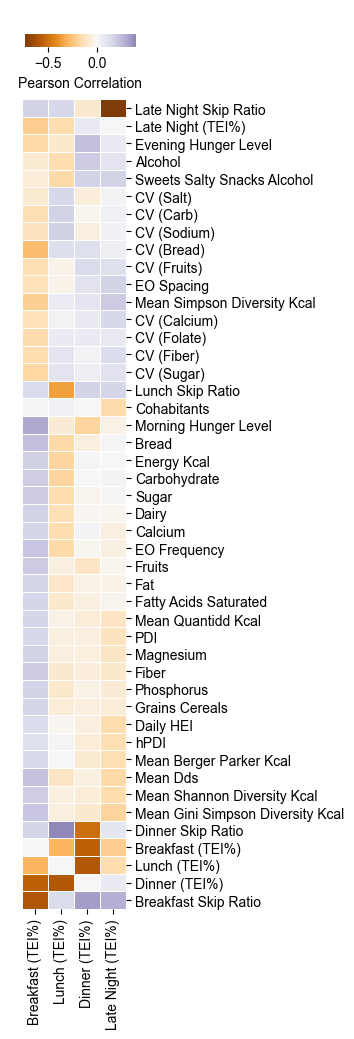

In [4]:
# Scale the energy distribution by meal type
mmm_no_small = merged_meals_with_meta[merged_meals_with_meta["energy_kcal_eaten"] > 0]
mmm_no_small = mmm_no_small[
    ~(mmm_no_small["combined_name"].apply(lambda x: "Tag standardised meal" in x))
]

scaled_energy_distribution = scale_feature_by_daily_intake(
    mmm_no_small, "energy_kcal_eaten"
)

meal_cols = ["Breakfast", "Lunch", "Dinner", "Late_night"]
meal_tei_cols = [col + " (TEI%)" for col in meal_cols]
rename_dict = {
    col: f"{col.replace('_', ' ').title()} (TEI%)"
    for col in meal_cols
    if col in scaled_energy_distribution.columns
}
scaled_energy_distribution.rename(columns=rename_dict, inplace=True)
meal_tei_cols = list(rename_dict.values())

# Calculate the mean of scaled energy distribution and merge with metadata
scaled_energy_distribution_mean_with_meta = (
    scaled_energy_distribution.drop(columns=["eaten_date"])
    .groupby("subject_key")
    .mean()
    .merge(meta, left_index=True, right_on="subject_key", how="inner")
)

# Compute correlations for meal types and filter based on threshold
corrs_meal_type = scaled_energy_distribution_mean_with_meta.corr(numeric_only=True)[
    meal_tei_cols
]
corrs_meal_type = corrs_meal_type[(corrs_meal_type.abs() >= 0.15).any(axis=1)]
corrs_meal_type = corrs_meal_type[
    ~corrs_meal_type.index.isin(
        ["alcohol_fg_eaten", "energy_kj_eaten", "others_fg_eaten"]
    )
]

for meal_type in meal_tei_cols:
    corrs_meal_type.loc[meal_type, meal_type] = 0

# Determine row colors based on variable type
row_colors = [
    get_var_type_color(get_var_type(index)) for index in corrs_meal_type.index
]

# Create a clustered heatmap
g = sns.clustermap(
    data=corrs_meal_type,
    cmap="PuOr",
    center=0,
    figsize=(3.7, 10.5),
    col_cluster=False,
    # row_colors=row_colors,
    dendrogram_ratio=0.1,
    linewidths=0.5,
    cbar_kws={"orientation": "horizontal", "label": "Pearson Correlation"},
    row_cluster=True,
    tree_kws={"linewidths": 0},  # Hide row cluster linkages
)

# Adjust the position and size of the color bar
g.cax.set_position([0.08, 0.95, 0.3, 0.012])

# Process and set y-axis labels
new_labels = [
    process_string(str(label.get_text()))
    for label in g.ax_heatmap.yaxis.get_majorticklabels()
]
g.ax_heatmap.set_yticklabels(new_labels)
g.ax_heatmap.set_ylabel("")

# Rotate x-axis labels for better readability
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90)

# Save the figure
g.savefig("../images/fig2/mealtype_EI_heatmap.png", dpi=300, bbox_inches="tight")

In [5]:
corrs_meal_type

,Breakfast (TEI%),Lunch (TEI%),Dinner (TEI%),Late Night (TEI%)
Breakfast (TEI%),0.000000,-0.297750,-0.555525,-0.214000
Dinner (TEI%),-0.555525,-0.591238,0.000000,0.066134
Late Night (TEI%),-0.214000,-0.159868,0.066134,0.000000
Lunch (TEI%),-0.297750,0.000000,-0.591238,-0.159868
cohabitants,0.008924,0.035926,0.003284,-0.163324
morning_hunger_level,0.304097,-0.079267,-0.185412,-0.041001
evening_hunger_level,-0.171121,-0.098290,0.223232,0.057153
PDI_Quintile,0.152294,-0.053680,-0.051063,-0.130981
hPDI_Quintile,0.114699,0.011815,-0.070823,-0.152998
energy_kcal_eaten,0.177467,-0.190291,0.013054,0.005093


### Model meal type energy intake w.r.t health outcomes

In [6]:
def prepare_subject_level_meal_data(
    df,
    meta_df,
    meal_types=None,
    outcome_var="eo_freq",
    covariates=None,
):
    if meal_types is None:
        meal_types = ["Breakfast", "Lunch", "Dinner", "Late_night"]

    if covariates is None:
        covariates = []

    # Average daily meal-energy proportions across recorded days
    subject_means = (
        df.groupby("subject_key", as_index=False)[meal_types]
        .mean()
        .rename(columns={meal: f"{meal}_mean" for meal in meal_types})
    )

    required_meta_columns = [
        "subject_key",
        outcome_var,
        *covariates,
    ]

    # Retain one metadata row per participant
    subject_meta = meta_df[required_meta_columns].drop_duplicates(subset="subject_key")

    subject_data = subject_means.merge(
        subject_meta,
        on="subject_key",
        how="inner",
        validate="one_to_one",
    )

    return subject_data

In [7]:
def analyze_mealtype_energy_intake_wrt_health_outcomes(
    subject_data,
    meal_var,
    outcome_var,
    covariates=None,
):
    if covariates:
        formula = f"{outcome_var} ~ {meal_var}_mean + " + " + ".join(covariates)
    else:
        formula = f"{outcome_var} ~ {meal_var}_mean"

    try:
        # Participant-level linear regression with robust standard errors
        result = ols(
            formula,
            data=subject_data,
        ).fit(cov_type="HC3")

        model_data = subject_data[
            [
                "subject_key",
                outcome_var,
                f"{meal_var}_mean",
                *(covariates or []),
            ]
        ].dropna()

        correlation = model_data[[f"{meal_var}_mean", outcome_var]].corr().iloc[0, 1]

        return {
            "model_summary": result.summary(),
            "fixed_effects": result.params,
            "aic": result.aic,
            "bic": result.bic,
            "n_subjects": model_data["subject_key"].nunique(),
            "n_observations": int(result.nobs),
            "correlation": correlation,
            "p_values": result.pvalues,
            "confidence_intervals": result.conf_int(),
            "model": result,
        }

    except Exception as e:
        print(f"\nError fitting model: {str(e)}")
        print(f"Formula used: {formula}")
        return None

In [35]:
def get_significance_stars(p_value):
    """Helper function to return significance stars"""
    if p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return ""


def plot_mealtype_energy_intake_effects(
    results,
    ax,
    target_var,
    meal_types=None,
):
    """
    Plot fixed effects with confidence intervals for meal timing analysis.

    Parameters:
    -----------
    results : dict
        Dictionary containing results from meal timing analysis
        Each meal type should have 'fixed_effects', 'confidence_intervals', and 'p_values'
    meal_types : list, optional
        List of meal types to plot. If None, uses all available meals
    figsize : tuple, optional
        Figure size in inches

    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    """
    if meal_types is None:
        meal_types = ["Breakfast", "Lunch", "Dinner", "Late_night"]

    # Prepare data
    effects_data = []
    for meal in meal_types:
        if meal in results:
            # Get fixed effect for meal timing
            effect = results[meal]["fixed_effects"][f"{meal}_mean"]

            # Get confidence intervals for meal timing
            ci = results[meal]["confidence_intervals"]
            ci_low = ci.loc[f"{meal}_mean", 0]
            ci_high = ci.loc[f"{meal}_mean", 1]

            # Get p-value
            p_value = results[meal]["p_values"][f"{meal}_mean"]

            effects_data.append(
                {
                    "meal": meal,
                    "effect": effect,
                    "ci_low": ci_low,
                    "ci_high": ci_high,
                    "p_value": p_value,
                }
            )

    # Convert to DataFrame for easier plotting
    df = pd.DataFrame(effects_data)

    # Create color mapping
    # colors = ['#2196F3', '#4CAF50', '#FFC107', '#FF5722']
    bar_colors = [
        "steelblue" if effect >= 0 else "darkorange" for effect in df["effect"]
    ]
    # bar_colors = ['limegreen' if effect >= 0 else 'salmon' for effect in df['effect']]

    # Plot bars
    bars = ax.bar(
        range(len(df)),
        df["effect"],
        # color= colors[:len(df)],
        color=bar_colors,
        width=0.5,
        alpha=0.7,
    )

    # Add error bars
    ax.errorbar(
        range(len(df)),
        df["effect"],
        yerr=[df["effect"] - df["ci_low"], df["ci_high"] - df["effect"]],
        fmt="none",
        color="black",
        capsize=4,
        capthick=0.75,
        elinewidth=0.75,
    )

    # Customize plot
    ax.axhline(y=0, color="black", linestyle="-", linewidth=0.8)
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels([f"{meal}\n(TEI%)" for meal in df["meal"]], rotation=0)

    # Add labels and title
    # ax.set_xlabel('Meal Type', fontsize=12)
    ax.set_ylabel(
        f"Effect on {process_string(target_var)} (β coefficient)", fontsize=11
    )
    # ax.set_title('Associations Between Meal Timing and BMI\nEffect sizes with 95% confidence intervals',
    #             fontsize=14, pad=20)

    # Add grid
    ax.grid(True, axis="y", linestyle="--", alpha=0.3)

    # Add significance stars
    max_effect = df["effect"].max()
    min_effect = df["effect"].min()
    y_range = max_effect - min_effect

    for i, row in df.iterrows():
        stars = get_significance_stars(row["p_value"])
        if stars:
            # Position stars above the error bars
            if row["effect"] >= 0:
                y_pos = row["ci_high"] + 0.5 * y_range * 0.05
            else:
                y_pos = row["ci_low"] - 3 * y_range * 0.05
            ax.text(i, y_pos, stars, ha="center", va="bottom", fontsize=12)

    # # Add legend for significance levels
    # legend_text = 'Significance levels:\n**** p < 0.001\n** p < 0.01\n* p < 0.05'
    # fig.text(0.5, 0.8, legend_text,
    #          ha='right', va='bottom', fontsize=10, style='italic')

    return ax


def run_analyze_mealtype_energy_intake_wrt_health_outcomes(
    subject_data,
    outcome_var,
    covariates=None,
    verbose=False,
    meal_types=None,
):
    if meal_types is None:
        meal_types = ["Breakfast", "Lunch", "Dinner", "Late_night"]

    results = {}

    for meal in meal_types:
        results[meal] = analyze_mealtype_energy_intake_wrt_health_outcomes(
            subject_data=subject_data,
            meal_var=meal,
            outcome_var=outcome_var,
            covariates=covariates,
        )

        if results[meal] is not None and verbose:
            print(f"\nAnalyzed {meal}")
            print(results[meal]["model_summary"])

    return results

In [36]:
mmm_no_small = merged_meals_with_meta[merged_meals_with_meta["energy_kcal_eaten"] > 0]
mmm_no_small = mmm_no_small[
    ~(mmm_no_small["combined_name"].apply(lambda x: "Tag standardised meal" in x))
]

# mmm_no_small = (
#     mmm_no_small.groupby(["subject_key", "eaten_date", "meal_type"])
#     .apply(lambda x: x.loc[x["energy_kcal_eaten"].idxmax()], include_groups=False)
#     .reset_index(drop=False)
# )

scaled_energy_distribution = scale_feature_by_daily_intake(
    mmm_no_small, "energy_kcal_eaten"
)

scaled_energy_distribution["eaten_date"] = pd.to_datetime(
    scaled_energy_distribution["eaten_date"]
)
scaled_energy_distribution["day_of_week"] = scaled_energy_distribution[
    "eaten_date"
].dt.dayofweek
scaled_energy_distribution["is_weekend"] = scaled_energy_distribution[
    "day_of_week"
].isin([5, 6])
### scaled_energy_distribution, result = analyze_meal_weekend_effect_with_ks(scaled_energy_distribution, 'Dinner')

In [37]:
meal_types = ["Breakfast", "Lunch", "Dinner", "Late_night"]
covariates = ["age", "bmi", "gender", "energy_kcal_eaten"]
outcome_var = "eo_freq"

subject_energy_distribution = prepare_subject_level_meal_data(
    df=scaled_energy_distribution,
    meta_df=meta,
    meal_types=meal_types,
    outcome_var=outcome_var,
    covariates=covariates,
)

print(subject_energy_distribution.shape)
print(subject_energy_distribution["subject_key"].nunique())

(962, 10)
962



Analyzed Breakfast
                            OLS Regression Results                            
Dep. Variable:                eo_freq   R-squared:                       0.346
Model:                            OLS   Adj. R-squared:                  0.342
Method:                 Least Squares   F-statistic:                     99.27
Date:                Fri, 10 Jul 2026   Prob (F-statistic):           2.44e-84
Time:                        14:25:54   Log-Likelihood:                -1126.3
No. Observations:                 962   AIC:                             2265.
Df Residuals:                     956   BIC:                             2294.
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         

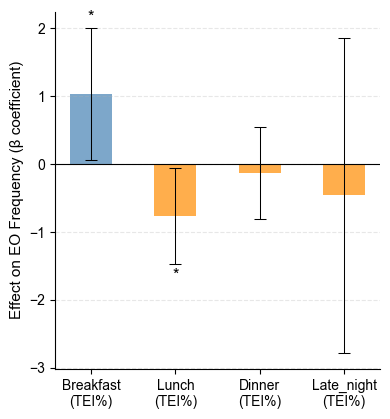

In [38]:
lm_results_mealtype_energy_intake_eo_freq = (
    run_analyze_mealtype_energy_intake_wrt_health_outcomes(
        subject_data=subject_energy_distribution,
        outcome_var=outcome_var,
        covariates=covariates,
        verbose=True,
    )
)

fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(4, 4.3))

plot_mealtype_energy_intake_effects(
    lm_results_mealtype_energy_intake_eo_freq,
    ax,
    outcome_var,
)

plt.tight_layout()
sns.despine()

plt.savefig(
    "../images/fig2/mealtype_energy_intake_effects_EOfreq.png",
    dpi=300,
    bbox_inches="tight",
)

In [39]:
for meal in meal_types:
    result = lm_results_mealtype_energy_intake_eo_freq[meal]
    term = f"{meal}_mean"

    beta = result["fixed_effects"][term]
    ci_low, ci_high = result["confidence_intervals"].loc[term]
    p_value = result["p_values"][term]

    print(
        f"{meal}: "
        f"beta={beta:.3f}, "
        f"95% CI [{ci_low:.3f}, {ci_high:.3f}], "
        f"p={p_value:.6g}, "
        f"n={result['n_observations']}"
    )

Breakfast: beta=1.034, 95% CI [0.063, 2.005], p=0.0369623, n=962
Lunch: beta=-0.764, 95% CI [-1.477, -0.051], p=0.0356338, n=962
Dinner: beta=-0.128, 95% CI [-0.801, 0.544], p=0.708698, n=962
Late_night: beta=-0.460, 95% CI [-2.777, 1.856], p=0.69687, n=962


In [40]:
scaled_energy_distribution

meal_type,subject_key,eaten_date,Breakfast,Dinner,Late_night,Lunch,day_of_week,is_weekend
0,02ae3856ca04,2018-11-27,0.075813,0.692561,0.000000,0.231626,1,False
1,02ae3856ca04,2018-11-28,0.061004,0.398336,0.140043,0.400616,2,False
2,02ae3856ca04,2018-11-29,0.180220,0.448086,0.175108,0.196587,3,False
3,02ae3856ca04,2018-11-30,0.000000,0.570480,0.203446,0.226074,4,False
4,02ae3856ca04,2018-12-01,0.000000,0.500849,0.245133,0.254018,5,True
...,...,...,...,...,...,...,...,...
13380,zznk4w,2022-09-20,0.000000,0.305119,0.000000,0.694881,1,False
13381,zznk4w,2022-09-21,0.000000,0.327831,0.000000,0.672169,2,False
13382,zznk4w,2022-09-22,0.032465,0.703487,0.000000,0.264048,3,False
13383,zznk4w,2022-09-23,0.213587,0.605394,0.068644,0.112375,4,False



Analyzed Breakfast
                            OLS Regression Results                            
Dep. Variable:                    bmi   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.085
Method:                 Least Squares   F-statistic:                     22.46
Date:                Fri, 10 Jul 2026   Prob (F-statistic):           2.42e-21
Time:                        14:26:02   Log-Likelihood:                -2584.6
No. Observations:                 962   AIC:                             5181.
Df Residuals:                     956   BIC:                             5210.
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         

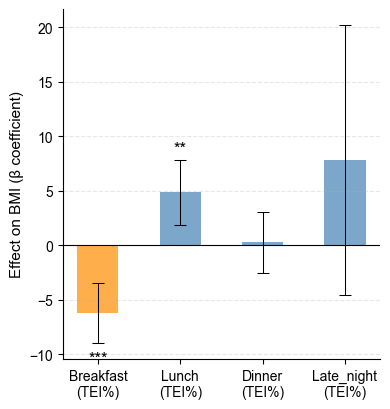

In [41]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(4, 4.2))

meal_types = ["Breakfast", "Lunch", "Dinner", "Late_night"]
outcome_var = "bmi"
covariates = ["age", "eo_freq", "gender", "energy_kcal_eaten"]

subject_energy_distribution_bmi = prepare_subject_level_meal_data(
    df=scaled_energy_distribution,
    meta_df=meta,
    meal_types=meal_types,
    outcome_var=outcome_var,
    covariates=covariates,
)

lm_results_mealtype_energy_intake_bmi = (
    run_analyze_mealtype_energy_intake_wrt_health_outcomes(
        subject_data=subject_energy_distribution_bmi,
        outcome_var=outcome_var,
        covariates=covariates,
        meal_types=meal_types,
        verbose=True,
    )
)

plot_mealtype_energy_intake_effects(
    lm_results_mealtype_energy_intake_bmi,
    ax,
    outcome_var,
)

plt.tight_layout()
sns.despine()

plt.savefig(
    "../images/fig2/mealtype_energy_intake_effects_BMI.png",
    dpi=300,
    bbox_inches="tight",
)

In [15]:
for meal in meal_types:
    result = lm_results_mealtype_energy_intake_bmi[meal]
    term = f"{meal}_mean"

    beta = result["fixed_effects"][term]
    ci_low, ci_high = result["confidence_intervals"].loc[term]
    p_value = result["p_values"][term]

    print(
        f"{meal}: "
        f"beta={beta:.3f}, "
        f"95% CI [{ci_low:.3f}, {ci_high:.3f}], "
        f"p={p_value:.6g}, "
        f"n={result['n_observations']}"
    )

Breakfast: beta=-6.233, 95% CI [-8.976, -3.491], p=8.42112e-06, n=962
Lunch: beta=4.843, 95% CI [1.830, 7.857], p=0.00163063, n=962
Dinner: beta=0.255, 95% CI [-2.523, 3.034], p=0.857027, n=962
Late_night: beta=7.839, 95% CI [-4.532, 20.211], p=0.21425, n=962


Meal-type values are participant-level averages across recorded days.


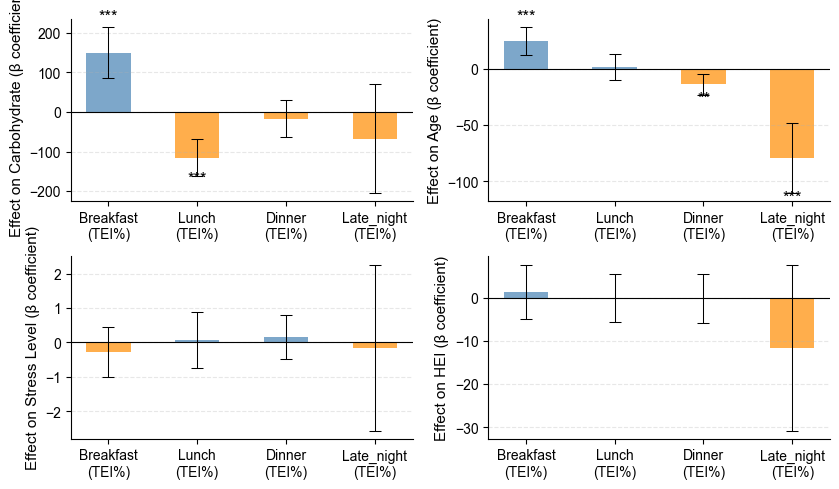

In [16]:
print("Meal-type values are participant-level averages across recorded days.")

meal_types = ["Breakfast", "Lunch", "Dinner", "Late_night"]

fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(8.5, 5))


# Carbohydrate intake
outcome_var = "carb_eaten"
covariates = ["age", "gender"]

subject_energy_distribution_carb = prepare_subject_level_meal_data(
    df=scaled_energy_distribution,
    meta_df=meta,
    meal_types=meal_types,
    outcome_var=outcome_var,
    covariates=covariates,
)

lm_results_mealtype_energy_intake_carb = (
    run_analyze_mealtype_energy_intake_wrt_health_outcomes(
        subject_data=subject_energy_distribution_carb,
        outcome_var=outcome_var,
        covariates=covariates,
        meal_types=meal_types,
    )
)

plot_mealtype_energy_intake_effects(
    lm_results_mealtype_energy_intake_carb,
    ax[0, 0],
    outcome_var,
)


# Age
outcome_var = "age"
covariates = ["bmi", "gender", "energy_kcal_eaten"]

subject_energy_distribution_age = prepare_subject_level_meal_data(
    df=scaled_energy_distribution,
    meta_df=meta,
    meal_types=meal_types,
    outcome_var=outcome_var,
    covariates=covariates,
)

lm_results_mealtype_energy_intake_age = (
    run_analyze_mealtype_energy_intake_wrt_health_outcomes(
        subject_data=subject_energy_distribution_age,
        outcome_var=outcome_var,
        covariates=covariates,
        meal_types=meal_types,
    )
)

plot_mealtype_energy_intake_effects(
    lm_results_mealtype_energy_intake_age,
    ax[0, 1],
    outcome_var,
)


# Stress level
outcome_var = "stress_level"
covariates = ["age", "bmi", "gender", "energy_kcal_eaten"]

subject_energy_distribution_stress = prepare_subject_level_meal_data(
    df=scaled_energy_distribution,
    meta_df=meta,
    meal_types=meal_types,
    outcome_var=outcome_var,
    covariates=covariates,
)

lm_results_mealtype_energy_intake_stress = (
    run_analyze_mealtype_energy_intake_wrt_health_outcomes(
        subject_data=subject_energy_distribution_stress,
        outcome_var=outcome_var,
        covariates=covariates,
        meal_types=meal_types,
    )
)

plot_mealtype_energy_intake_effects(
    lm_results_mealtype_energy_intake_stress,
    ax[1, 0],
    outcome_var,
)


# Healthy Eating Index
outcome_var = "HEI"
covariates = ["age", "bmi", "gender"]

subject_energy_distribution_hei = prepare_subject_level_meal_data(
    df=scaled_energy_distribution,
    meta_df=meta,
    meal_types=meal_types,
    outcome_var=outcome_var,
    covariates=covariates,
)

lm_results_mealtype_energy_intake_hei = (
    run_analyze_mealtype_energy_intake_wrt_health_outcomes(
        subject_data=subject_energy_distribution_hei,
        outcome_var=outcome_var,
        covariates=covariates,
        meal_types=meal_types,
    )
)

plot_mealtype_energy_intake_effects(
    lm_results_mealtype_energy_intake_hei,
    ax[1, 1],
    outcome_var,
)

plt.tight_layout()
sns.despine()

plt.savefig(
    "../images/supplementary/mealtype_energy_intake_effects_others.png",
    dpi=300,
    bbox_inches="tight",
)

In [17]:
meal_tei_cols

['Breakfast (TEI%)', 'Lunch (TEI%)', 'Dinner (TEI%)', 'Late Night (TEI%)']

In [18]:
for meal in meal_types:
    print(
        f"{meal} BMI model fixed effects:\n"
        f"{lm_results_mealtype_energy_intake_bmi[meal]['fixed_effects']}\n"
    )

Breakfast BMI model fixed effects:
Intercept            20.810055
gender[T.male]        0.804975
Breakfast_mean       -6.233344
age                   0.069144
eo_freq              -0.313486
energy_kcal_eaten     0.001013
dtype: float64

Lunch BMI model fixed effects:
Intercept            18.545346
gender[T.male]        0.865935
Lunch_mean            4.843449
age                   0.062824
eo_freq              -0.338814
energy_kcal_eaten     0.000966
dtype: float64

Dinner BMI model fixed effects:
Intercept            20.714799
gender[T.male]        0.869343
Dinner_mean           0.255369
age                   0.064446
eo_freq              -0.378669
energy_kcal_eaten     0.000836
dtype: float64

Late_night BMI model fixed effects:
Intercept            20.629343
gender[T.male]        0.836791
Late_night_mean       7.839313
age                   0.066589
eo_freq              -0.374972
energy_kcal_eaten     0.000851
dtype: float64



In [19]:
for meal in meal_types:
    print(
        f"{meal} EO frequency model fixed effects:\n"
        f"{lm_results_mealtype_energy_intake_eo_freq[meal]['fixed_effects']}\n"
    )

Breakfast EO frequency model fixed effects:
Intercept            1.811638
gender[T.male]      -0.523932
Breakfast_mean       1.033785
age                  0.009262
bmi                 -0.015120
energy_kcal_eaten    0.001445
dtype: float64

Lunch EO frequency model fixed effects:
Intercept            2.199646
gender[T.male]      -0.535318
Lunch_mean          -0.764268
age                  0.010413
bmi                 -0.016307
energy_kcal_eaten    0.001460
dtype: float64

Dinner EO frequency model fixed effects:
Intercept            1.947724
gender[T.male]      -0.536851
Dinner_mean         -0.128172
age                  0.010256
bmi                 -0.018124
energy_kcal_eaten    0.001491
dtype: float64

Late_night EO frequency model fixed effects:
Intercept            1.893056
gender[T.male]      -0.535659
Late_night_mean     -0.460384
age                  0.010210
bmi                 -0.017994
energy_kcal_eaten    0.001490
dtype: float64



## Mediation analysis

In [20]:
def prepare_subject_level_mediation_data(
    df,
    meta_df,
    meal_types=None,
    covariates=None,
):
    if meal_types is None:
        meal_types = ["Breakfast", "Lunch", "Dinner", "Late_night"]

    if covariates is None:
        covariates = []

    meal_means = (
        df.groupby("subject_key", as_index=False)[meal_types]
        .mean()
        .rename(columns={meal: f"{meal}_mean" for meal in meal_types})
    )

    required_columns = [
        "subject_key",
        "eo_freq",
        "bmi",
        *covariates,
    ]

    subject_meta = meta_df[required_columns].copy()

    # Confirm that participant-level variables do not vary within participants
    inconsistent = (
        subject_meta.groupby("subject_key")[required_columns[1:]]
        .nunique(dropna=False)
        .gt(1)
        .any(axis=1)
    )

    if inconsistent.any():
        problematic_subjects = inconsistent[inconsistent].index.tolist()
        raise ValueError(
            "Participant-level metadata vary within some participants: "
            f"{problematic_subjects[:10]}"
        )

    subject_meta = subject_meta.drop_duplicates("subject_key")

    subject_data = meal_means.merge(
        subject_meta,
        on="subject_key",
        how="inner",
        validate="one_to_one",
    )

    return subject_data

In [21]:
def run_mediation_analysis(
    subject_data,
    meal_var,
    covariates=None,
    n_boot=5000,
    random_state=42,
):
    """
    Participant-level mediation analysis:

    X: mean meal-specific proportion of daily energy intake
    M: eating occasion frequency
    Y: BMI
    """

    if covariates is None:
        covariates = []

    exposure = f"{meal_var}_mean"

    analysis_columns = [
        exposure,
        "eo_freq",
        "bmi",
        *covariates,
    ]

    analysis_df = subject_data[analysis_columns].dropna().reset_index(drop=True)

    covariate_terms = " + ".join(covariates)

    formula_m = f"eo_freq ~ {exposure}"
    formula_y = f"bmi ~ {exposure} + eo_freq"
    formula_t = f"bmi ~ {exposure}"

    if covariate_terms:
        formula_m += f" + {covariate_terms}"
        formula_y += f" + {covariate_terms}"
        formula_t += f" + {covariate_terms}"

    # Path a: X -> M
    results_m = ols(
        formula_m,
        data=analysis_df,
    ).fit(cov_type="HC3")

    # Paths b and c': X + M -> Y
    results_y = ols(
        formula_y,
        data=analysis_df,
    ).fit(cov_type="HC3")

    # Path c: total effect X -> Y
    results_t = ols(
        formula_t,
        data=analysis_df,
    ).fit(cov_type="HC3")

    a_path = results_m.params[exposure]
    b_path = results_y.params["eo_freq"]
    c_prime_path = results_y.params[exposure]
    c_path = results_t.params[exposure]

    indirect_effect = a_path * b_path

    proportion_mediated = (
        indirect_effect / c_path if not np.isclose(c_path, 0) else np.nan
    )

    # Participant-level bootstrap for the indirect effect
    rng = np.random.default_rng(random_state)
    n_subjects = len(analysis_df)

    bootstrap_indirect = []

    for _ in range(n_boot):
        sample_indices = rng.integers(
            low=0,
            high=n_subjects,
            size=n_subjects,
        )

        bootstrap_df = analysis_df.iloc[sample_indices].reset_index(drop=True)

        try:
            bootstrap_m = ols(
                formula_m,
                data=bootstrap_df,
            ).fit()

            bootstrap_y = ols(
                formula_y,
                data=bootstrap_df,
            ).fit()

            bootstrap_indirect.append(
                bootstrap_m.params[exposure] * bootstrap_y.params["eo_freq"]
            )

        except Exception:
            continue

    bootstrap_indirect = np.asarray(bootstrap_indirect)

    indirect_ci_low, indirect_ci_high = np.percentile(
        bootstrap_indirect,
        [2.5, 97.5],
    )

    indirect_p = min(
        1.0,
        2
        * min(
            np.mean(bootstrap_indirect <= 0),
            np.mean(bootstrap_indirect >= 0),
        ),
    )

    return {
        "a_path": {
            "coef": a_path,
            "p_value": results_m.pvalues[exposure],
            "confidence_interval": results_m.conf_int().loc[exposure].tolist(),
        },
        "b_path": {
            "coef": b_path,
            "p_value": results_y.pvalues["eo_freq"],
            "confidence_interval": results_y.conf_int().loc["eo_freq"].tolist(),
        },
        "c_path": {
            "coef": c_path,
            "p_value": results_t.pvalues[exposure],
            "confidence_interval": results_t.conf_int().loc[exposure].tolist(),
        },
        "c_prime_path": {
            "coef": c_prime_path,
            "p_value": results_y.pvalues[exposure],
            "confidence_interval": results_y.conf_int().loc[exposure].tolist(),
        },
        "indirect_effect": indirect_effect,
        "indirect_effect_ci": [
            indirect_ci_low,
            indirect_ci_high,
        ],
        "indirect_effect_p": indirect_p,
        "total_effect": c_path,
        "direct_effect": c_prime_path,
        "proportion_mediated": proportion_mediated,
        "n_subjects": n_subjects,
        "n_successful_bootstraps": len(bootstrap_indirect),
        "model_summaries": {
            "path_a": results_m,
            "path_b_and_direct": results_y,
            "total_effect": results_t,
        },
    }

In [22]:
def analyze_all_meals_mediation(
    subject_data,
    covariates=None,
    meal_types=None,
    n_boot=5000,
    random_state=42,
):
    if meal_types is None:
        meal_types = ["Breakfast", "Lunch", "Dinner", "Late_night"]

    results = {}

    for i, meal in enumerate(meal_types):
        print(f"\nAnalyzing mediation for {meal}...")

        results[meal] = run_mediation_analysis(
            subject_data=subject_data,
            meal_var=meal,
            covariates=covariates,
            n_boot=n_boot,
            random_state=random_state + i,
        )

    return results

In [23]:
import networkx as nx


def plot_mediation_network(results, meal_var, ax, figtext_pos=(0.02, 0.02)):
    """
    Visualize mediation analysis results using NetworkX.

    Parameters:
    -----------
    results : dict
        Dictionary containing mediation analysis results with paths and effects
    meal_var : str
        Name of the meal timing variable
    ax : matplotlib axis
        Axis to draw the network on
    figtext_pos : tuple
        Position for the summary statistics text (x, y)

    Returns:
    --------
    ax : matplotlib axis object
    """
    # Create directed graph
    G = nx.DiGraph()

    # Add nodes with labels
    nodes = [
        ("X", f'{" ".join(meal_var.split("_"))}\nTiming'),
        ("M", "Eating\nFrequency"),
        ("Y", "BMI"),
    ]
    G.add_nodes_from([node[0] for node in nodes])

    # Add edges with paths
    edges = [
        ("X", "M", {"path": "a", "data": results["a_path"]}),
        ("M", "Y", {"path": "b", "data": results["b_path"]}),
        ("X", "Y", {"path": "c'", "data": results["c_prime_path"]}),
    ]
    G.add_edges_from([(e[0], e[1], e[2]) for e in edges])

    # Set positions for nodes with more spacing
    pos = {"X": (-1, 0), "M": (0, 1), "Y": (1, 0)}

    # Set axis limits with padding
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-0.5, 1.5)

    # Draw nodes
    node_colors = ["lightblue"] * len(G.nodes())
    node_size = 2000
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_size, ax=ax)

    # Draw node labels
    node_labels = dict(nodes)
    nx.draw_networkx_labels(G, pos, node_labels, font_size=10)

    # Function to add significance stars
    def get_stars(p_value):
        if p_value < 0.001:
            return "***"
        elif p_value < 0.01:
            return "**"
        elif p_value < 0.05:
            return "*"
        return ""

    # Draw edges with color based on beta value
    for edge in edges:
        source, target, data = edge
        beta = data["data"]["coef"]
        # Set color based on beta value
        color = "red" if beta < 0 else "black"

        # Draw curved arrows with appropriate color
        plt.annotate(
            "",
            xy=pos[target],
            xycoords="data",
            xytext=pos[source],
            textcoords="data",
            arrowprops=dict(
                arrowstyle="->",
                connectionstyle="arc3,rad=0.2",
                color=color,  # Set arrow color
                lw=2,
                shrinkA=30,
                shrinkB=30,
            ),
        )

    # Add edge labels with path names, coefficients and significance
    edge_labels = {}
    for edge in edges:
        source, target, data = edge
        path_name = data["path"]
        coef = data["data"]["coef"]
        p_value = data["data"]["p_value"]
        # Color the beta value in the label text
        color = "red" if coef < 0 else "black"
        edge_labels[(source, target)] = {
            "text": f"Path {path_name}\nβ = {coef:.3f}{get_stars(p_value)}",
            "color": color,
        }

    # Calculate edge label positions with offset to avoid overlap with arrows
    edge_label_pos = {}
    for source, target in edge_labels.keys():
        source_pos = pos[source]
        target_pos = pos[target]
        mid_x = (source_pos[0] + target_pos[0]) / 2
        mid_y = (source_pos[1] + target_pos[1]) / 2

        # Add offset based on the path
        if source == "X" and target == "M":  # Path a
            mid_y += 0.2
        elif source == "M" and target == "Y":  # Path b
            mid_y += 0.2
        elif source == "X" and target == "Y":  # Path c'
            mid_y -= 0.2

        edge_label_pos[(source, target)] = (mid_x, mid_y)

    # Add edge labels at calculated positions with appropriate colors
    for (source, target), label_info in edge_labels.items():
        x, y = edge_label_pos[(source, target)]
        plt.text(
            x,
            y,
            label_info["text"],
            color=label_info["color"],
            horizontalalignment="center",
            verticalalignment="center",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7),
        )

    # Remove axis
    ax.set_axis_off()

    # Add effect sizes at specified position
    plt.figtext(
        figtext_pos[0],
        figtext_pos[1],
        f"Indirect effect (a×b): {results['indirect_effect']:.3f}\n"
        + f"Direct effect (c'): {results['c_prime_path']['coef']:.3f}\n"
        + f"Total effect (c): {results['total_effect']:.3f}\n"
        + f"Proportion mediated: {results['proportion_mediated']:.3f}",
        ha="left",
        va="bottom",
    )

    return ax

In [24]:
meal_types = ["Breakfast", "Lunch", "Dinner", "Late_night"]
mediation_covariates = ["age", "gender", "energy_kcal_eaten"]

mediation_subject_data = prepare_subject_level_mediation_data(
    df=scaled_energy_distribution,
    meta_df=meta,
    meal_types=meal_types,
    covariates=mediation_covariates,
)

print(mediation_subject_data.shape)
print(mediation_subject_data["subject_key"].nunique())

mediation_results = analyze_all_meals_mediation(
    subject_data=mediation_subject_data,
    covariates=mediation_covariates,
    meal_types=meal_types,
    n_boot=5000,
    random_state=42,
)

(962, 10)
962

Analyzing mediation for Breakfast...

Analyzing mediation for Lunch...

Analyzing mediation for Dinner...

Analyzing mediation for Late_night...


In [25]:
for meal in meal_types:
    result = mediation_results[meal]
    ci_low, ci_high = result["indirect_effect_ci"]

    print(f"\n{meal} mediation results")
    print(
        f"Path a: "
        f"beta={result['a_path']['coef']:.3f}, "
        f"p={result['a_path']['p_value']:.6g}"
    )
    print(
        f"Path b: "
        f"beta={result['b_path']['coef']:.3f}, "
        f"p={result['b_path']['p_value']:.6g}"
    )
    print(
        f"Indirect effect: "
        f"{result['indirect_effect']:.3f}, "
        f"95% bootstrap CI "
        f"[{ci_low:.3f}, {ci_high:.3f}], "
        f"p={result['indirect_effect_p']:.6g}"
    )
    print(f"Direct effect: " f"{result['direct_effect']:.3f}")
    print(f"Total effect: " f"{result['total_effect']:.3f}")
    print(f"Proportion mediated: " f"{result['proportion_mediated']:.3f}")
    print(f"n={result['n_subjects']}")


Breakfast mediation results
Path a: beta=1.133, p=0.0208619
Path b: beta=-0.313, p=0.0324918
Indirect effect: -0.355, 95% bootstrap CI [-0.900, -0.017], p=0.0328
Direct effect: -6.233
Total effect: -6.589
Proportion mediated: 0.054
n=962

Lunch mediation results
Path a: beta=-0.848, p=0.0194129
Path b: beta=-0.339, p=0.0198958
Indirect effect: 0.287, 95% bootstrap CI [0.010, 0.718], p=0.0364
Direct effect: 4.843
Total effect: 5.131
Proportion mediated: 0.056
n=962

Dinner mediation results
Path a: beta=-0.134, p=0.696489
Path b: beta=-0.379, p=0.0107141
Indirect effect: 0.051, 95% bootstrap CI [-0.217, 0.356], p=0.7016
Direct effect: 0.255
Total effect: 0.306
Proportion mediated: 0.165
n=962

Late_night mediation results
Path a: beta=-0.606, p=0.609511
Path b: beta=-0.375, p=0.0113565
Indirect effect: 0.227, 95% bootstrap CI [-0.736, 1.170], p=0.6084
Direct effect: 7.839
Total effect: 8.066
Proportion mediated: 0.028
n=962


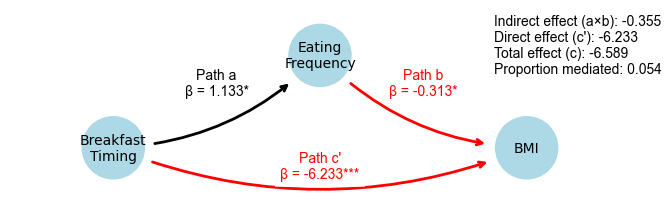

In [26]:
mediation_results_breakfast = mediation_results["Breakfast"]

fig, ax = plt.subplots(figsize=(8, 2.4))

plot_mediation_network(
    mediation_results_breakfast,
    meal_var="Breakfast",
    ax=ax,
    figtext_pos=(0.73, 0.6),
)

plt.savefig(
    "../images/fig2/mediation_network_breakfast.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

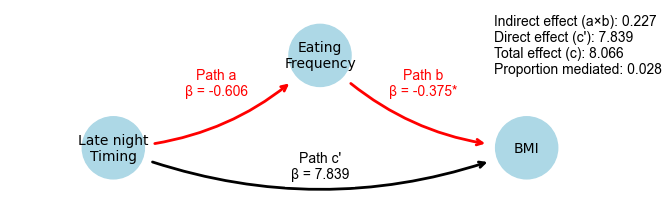

In [27]:
mediation_results_late_night = mediation_results["Late_night"]

fig, ax = plt.subplots(figsize=(8, 2.4))

plot_mediation_network(
    mediation_results_late_night,
    meal_var="Late_night",
    ax=ax,
    figtext_pos=(0.73, 0.6),
)

plt.savefig(
    "../images/fig2/mediation_network_late_night.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

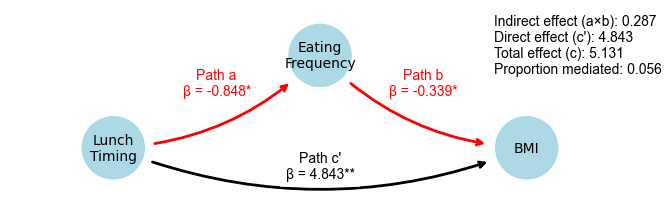

In [28]:
mediation_results_lunch = mediation_results["Lunch"]

fig, ax = plt.subplots(figsize=(8, 2.4))

plot_mediation_network(
    mediation_results_lunch,
    meal_var="Lunch",
    ax=ax,
    figtext_pos=(0.73, 0.6),
)

plt.savefig(
    "../images/fig2/mediation_network_lunch.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()